# 03 — Can strategies rebalance the wallet without PM? (cross-basket, no Guard)

> Run top to bottom.

`02_basket_with_without_pm.ipynb` compared PM to a competitor deliberately confined to
one pair (USDC/USDT) — it never even tried to touch WETH. This notebook removes that
constraint entirely: **no PM is registered**, which means there's no Guard either — the
real `BasketScopeGuard.sol` only exists because it's installed on PM's own dedicated
wallet (ADR-0002); a wallet with no PM never has this Guard in the first place. So instead
of one confined competitor, we deploy an independent, profit-seeking
`XYCCompetitorStrategy` on **every pairwise combination** of the wallet's tokens
(WETH/USDC, WETH/USDT, USDC/USDT) — nothing stops any of them from moving WETH.

The question: can this fully-connected set of ordinary, uncoordinated, profit-seeking
strategies rebalance the wallet anywhere close to what PM achieves alone (`01_pm_alone.ipynb`)
or with a confined competitor (`02_basket_with_without_pm.ipynb`)?

Uses `aqua_sim.scenarios.cross_basket_no_pm.build_world` (the "no PM" arm) and
`aqua_sim.scenarios.basket_with_without_pm.build_world(with_pm=True, ...)` (the PM
baseline, same as `02`'s "with PM" arm) directly. Prices are synthetic-only (R2).

In [1]:
import numpy as np

from aqua_sim.scenarios import basket_with_without_pm, cross_basket_no_pm

N_STEPS = 2000
N_SEEDS = 10

te_pm, te_no_pm = [], []
for seed in range(N_SEEDS):
    world_pm = basket_with_without_pm.build_world(with_pm=True, seed=seed)
    world_pm.run(N_STEPS)
    te_pm.append(np.mean(world_pm.metrics.tracking_error_path))

    world_no_pm = cross_basket_no_pm.build_world(seed=seed)
    world_no_pm.run(N_STEPS)
    te_no_pm.append(np.mean(world_no_pm.metrics.tracking_error_path))

    print(f"seed {seed}: with PM = {te_pm[-1]:.4%}, all-pairs no PM = {te_no_pm[-1]:.4%}")

te_pm, te_no_pm = np.array(te_pm), np.array(te_no_pm)
print(f"\nmean across seeds: with PM = {te_pm.mean():.4%}, all-pairs no PM = {te_no_pm.mean():.4%}")

print("\nUnlike 02's confined competitor, WETH is free to move here -- confirm it actually does:")
world_check = cross_basket_no_pm.build_world(seed=1)
initial_weth = world_check.token_balances["WETH"]
world_check.run(N_STEPS)
assert world_check.token_balances["WETH"] != initial_weth, "WETH should move -- nothing confines these competitors to one group"
assert world_check.blocked_trades == [], "no PM means no Guard -- nothing should ever be blocked here"
print(f"WETH balance: {initial_weth} at start, {world_check.token_balances['WETH']:.4f} after {N_STEPS} steps -- moved freely, nothing blocked")

seed 0: with PM = 0.0271%, all-pairs no PM = 16.6687%
seed 1: with PM = 0.0277%, all-pairs no PM = 16.6693%
seed 2: with PM = 0.0297%, all-pairs no PM = 16.6687%
seed 3: with PM = 0.0209%, all-pairs no PM = 16.6704%
seed 4: with PM = 0.0239%, all-pairs no PM = 16.6693%
seed 5: with PM = 0.0234%, all-pairs no PM = 16.6699%
seed 6: with PM = 0.0239%, all-pairs no PM = 16.6702%


seed 7: with PM = 0.0330%, all-pairs no PM = 16.6693%
seed 8: with PM = 0.0282%, all-pairs no PM = 16.6686%
seed 9: with PM = 0.0229%, all-pairs no PM = 16.6701%

mean across seeds: with PM = 0.0261%, all-pairs no PM = 16.6694%

Unlike 02's confined competitor, WETH is free to move here -- confirm it actually does:
WETH balance: 10.0 at start, 7.2114 after 2000 steps -- moved freely, nothing blocked


## Visual: portfolio balance

Same comparison, plotting each group's oracle-valued virtual balance (ADR-0003) and the
total over time, one representative seed.

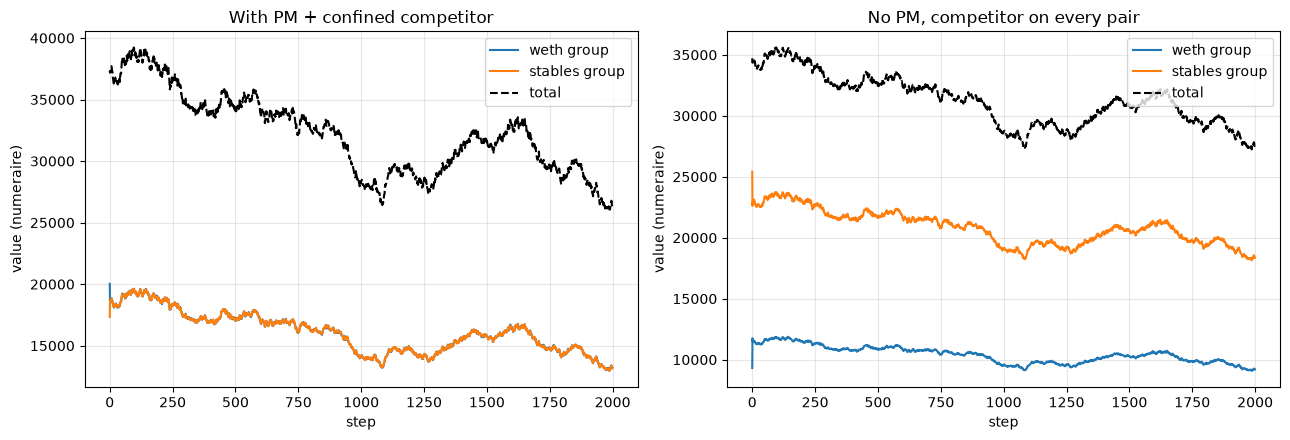

final total portfolio value: with PM = 26,369.63, all-pairs no PM = 27,553.29


In [2]:
import matplotlib.pyplot as plt

world_pm = basket_with_without_pm.build_world(with_pm=True, seed=0)
world_pm.run(N_STEPS)
world_no_pm = cross_basket_no_pm.build_world(seed=0)
world_no_pm.run(N_STEPS)

total_pm = np.array(world_pm.metrics.value_a_path) + np.array(world_pm.metrics.value_b_path)
total_no_pm = np.array(world_no_pm.metrics.value_a_path) + np.array(world_no_pm.metrics.value_b_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(world_pm.metrics.value_a_path, label="weth group")
ax1.plot(world_pm.metrics.value_b_path, label="stables group")
ax1.plot(total_pm, label="total", linestyle="--", color="black")
ax1.set_xlabel("step")
ax1.set_ylabel("value (numeraire)")
ax1.set_title("With PM + confined competitor")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(world_no_pm.metrics.value_a_path, label="weth group")
ax2.plot(world_no_pm.metrics.value_b_path, label="stables group")
ax2.plot(total_no_pm, label="total", linestyle="--", color="black")
ax2.set_xlabel("step")
ax2.set_ylabel("value (numeraire)")
ax2.set_title("No PM, competitor on every pair")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"final total portfolio value: with PM = {total_pm[-1]:,.2f}, all-pairs no PM = {total_no_pm[-1]:,.2f}")

## Summary

**Yes, it's possible for other strategies to move the wallet's balance without PM** — the
Guard has nothing to enforce with no PM registered, so a competitor on every pair is free
to touch WETH. But **"possible" isn't "equivalent to PM"**: mean tracking error against
the declared 50/50 target lands around **16.67%**, essentially identical across all 10
seeds (16.67-16.67%, vs. PM's 0.02-0.03%) — about **600x further from target than PM**,
and far worse than even `02`'s confined-competitor "without PM" arm (which ranged
4-14% depending on the seed's price path).

**Why so consistent across seeds, unlike `02`'s "without PM" arm:** each pairwise
`XYCCompetitorStrategy` only enforces *local* price consistency on its own pair — it has
no idea a declared 50/50 WETH-vs-stables target even exists, only "does my own pool's
price match the market rate for these two tokens." Three independent pairs converge to
one relative-price-consistent equilibrium fairly deterministically, regardless of the
specific random price path — but that equilibrium has nothing to do with any portfolio-
level allocation target. This is the concrete difference between *arbitrage* (price
consistency, what any of these strategies does on its own) and *portfolio management*
(a declared target weight PM actively corrects toward) — a fully-connected set of
ordinary arbitrageurs gives you the former for free, never the latter.

Total portfolio value ended slightly *higher* without PM in this run (27,553 vs. 26,370)
— not a contradiction: cost here isn't fee/gas drag (there's barely any without PM's
frequent gas-gated corrections), it's value sitting in the wrong-weighted allocation
relative to what the LP actually declared. Tracking error, not total value, is the metric
that captures that.